# Named Entity Recognition (NER) Pipeline
## Complete Pipeline: Crawl → Preprocess → label → Encode →  Train → Evaluate → Predict

This notebook contains all steps for building an NER system:
1. **Day1 - Crawl**: Data collection from Google News
2. **Day2 - Preprocess**: Text cleaning and preprocessing
3. **Day3 - Encode**: NER labeling with spaCy
5. **Day4 - Relabeling**: Apply custom entity mappings for improved accuracy
6. **Day5 - Train**: Model training with DistilBERT
7. **Day6 - Results**: Evaluation, visualization, and prediction

---

# Step 1: Data Crawling (Day1)

Collect news articles from Google News using:
- Chromium browser for page rendering
- Newspaper3k for article extraction
- GoogleNewsDecoder for URL decoding

In [87]:
import sys

!{sys.executable} -m pip install -q pandas newspaper3k googlenewsdecoder DrissionPage nltk spacy lxml_html_clean
!{sys.executable} -m spacy download en_core_web_sm


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
      --------------------------------------- 0.3/12.8 MB ? eta -:--:--
     -- ------------------------------------- 0.8/12.8 MB 1.5 MB/s eta 0:00:08
     --- ------------------------------------ 1.0/12.8 MB 1.7 MB/s eta 0:00:07
     ------ --------------------------------- 2.1/12.8 MB 2.4 MB/s eta 0:00:05
     ------ --------------------------------- 2.1/12.8 MB 2.4 MB/s eta 0:00:05
     --------- ------------------------------ 2.9/12.8 MB 2.2 MB/s eta 0:00:05
     ---------- ----------------------------- 3.4/12.8 MB 2.3 MB/s eta 0:00:05
     ------------- -------------------------- 4.2/12.8 MB 2.5 MB/s eta 0:00:04
     --------------- ------------------------ 5.0/12.8 MB 2.6 MB/s eta 0:00:03
     ---


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
# CODE FROM Day1_Crawl/crawl.py
import pandas as pd
from newspaper import Article
import nltk
from googlenewsdecoder import new_decoderv1
from DrissionPage import ChromiumPage, ChromiumOptions
import time
import os

## Load Crawled Data

In [5]:
# Load the crawled data (or use existing file)
df = pd.read_csv("Day1_Crawl/ket_qua_sentence.csv")

print("=" * 50)
print("DATA EXPLORATION (Day1)")
print("=" * 50)
print(f"Dataset size: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nFirst 5 rows:")
df.head()

DATA EXPLORATION (Day1)
Dataset size: (3680, 2)
Columns: ['Title', 'Sentence']

First 5 rows:


,Title,Sentence
0,US judge halts Trump plan to end protections f...,Summary Companies Lawsuit claims Noem hostil...
1,US judge halts Trump plan to end protections f...,"U.S. District Judge Ana Reyes in Washington, D..."
2,US judge halts Trump plan to end protections f...,The move would have taken effect on Wednesday ...
3,US judge halts Trump plan to end protections f...,The Reuters Inside Track newsletter is your es...
4,US judge halts Trump plan to end protections f...,"Reyes, who was appointed by Democratic former ..."


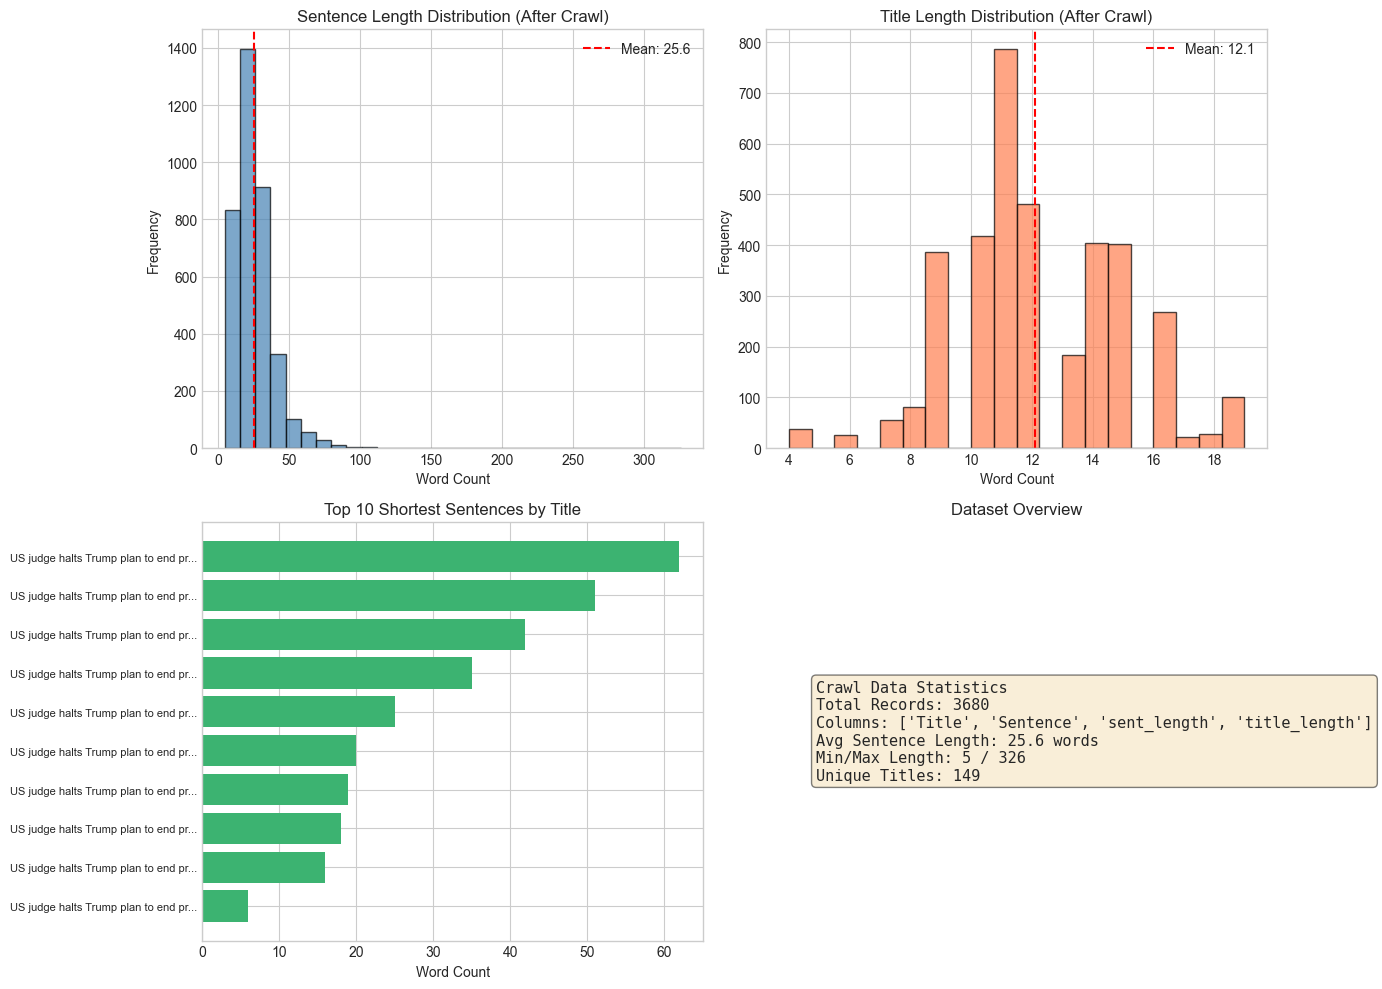

Saved: charts/after_crawl_analysis.png


In [33]:
# Data Visualization: After Crawl
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Load raw crawl data
df_raw = pd.read_csv('Day1_Crawl/ket_qua_sentence.csv')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Sentence length distribution
df_raw['sent_length'] = df_raw['Sentence'].apply(lambda x: len(str(x).split()))
axes[0, 0].hist(df_raw['sent_length'], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 0].axvline(df_raw['sent_length'].mean(), color='red', linestyle='--', label='Mean: ' + str(round(df_raw['sent_length'].mean(), 1)))
axes[0, 0].set_xlabel('Word Count')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Sentence Length Distribution (After Crawl)')
axes[0, 0].legend()

# 2. Title length distribution
df_raw['title_length'] = df_raw['Title'].apply(lambda x: len(str(x).split()))
axes[0, 1].hist(df_raw['title_length'], bins=20, edgecolor='black', alpha=0.7, color='coral')
axes[0, 1].axvline(df_raw['title_length'].mean(), color='red', linestyle='--', label='Mean: ' + str(round(df_raw['title_length'].mean(), 1)))
axes[0, 1].set_xlabel('Word Count')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Title Length Distribution (After Crawl)')
axes[0, 1].legend()

# 3. Sample entries
sample_data = df_raw.head(10)[['Title', 'sent_length']].copy().sort_values('sent_length', ascending=True)
axes[1, 0].barh(range(len(sample_data)), sample_data['sent_length'], color='mediumseagreen')
axes[1, 0].set_yticks(range(len(sample_data)))
axes[1, 0].set_yticklabels([t[:35] + '...' if len(t) > 35 else t for t in sample_data['Title']], fontsize=8)
axes[1, 0].set_xlabel('Word Count')
axes[1, 0].set_title('Top 10 Shortest Sentences by Title')

stats_text = (
    "Crawl Data Statistics\n"
    "Total Records: " + str(len(df_raw)) + "\n"
    "Columns: " + str(df_raw.columns.tolist()) + "\n"
    "Avg Sentence Length: " + str(round(df_raw['sent_length'].mean(), 1)) + " words\n"
    "Min/Max Length: " + str(df_raw['sent_length'].min()) + " / " + str(df_raw['sent_length'].max()) + "\n"
    "Unique Titles: " + str(df_raw['Title'].nunique())
)
axes[1, 1].text(0.1, 0.5, stats_text, fontsize=11, family='monospace', verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
axes[1, 1].axis('off')
axes[1, 1].set_title('Dataset Overview')

plt.tight_layout()
plt.savefig('charts/after_crawl_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: charts/after_crawl_analysis.png')

In [6]:
# More exploration
print(f"Unique titles: {df['Title'].nunique()}")
print(f"Missing values:\n{df.isna().sum()}")
print(f"\nSample sentences:")
for i, sent in enumerate(df['Sentence'].head(3)):
    print(f"{i+1}. {sent[:100]}...")

Unique titles: 149
Missing values:
Title       0
Sentence    0
dtype: int64

Sample sentences:
1. Summary  Companies  Lawsuit claims Noem hostile to nonwhite immigrants  Judge says that claim 'seems...
2. U.S. District Judge Ana Reyes in Washington, D.C., halted, opens new tab the U.S. Department of Home...
3. The move would have taken effect on Wednesday despite spiraling violence there that has displaced mo...


---

# Step 2: Text Preprocessing (Day2)

Preprocessing steps:
- Remove noise (emails, special patterns)
- Tokenization
- Remove stopwords
- Lemmatization

In [7]:
import pandas as pd
import re
import os
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from collections import Counter

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

class TextPreprocessor:
    """Text preprocessing class for cleaning news data"""

    def __init__(self):
        noise_patterns = [
            r'summary.*?-',
            r'opens new tab',
            r'reuters inside track.*',
            r'reporting by.*',
            r'editing by.*',
            r'our standards.*',
            r'can be reached at.*'
        ]
        self.noise_regex = [re.compile(p, re.IGNORECASE) for p in noise_patterns]

    def clean_text(self, text):
        """Clean and preprocess text"""
        if pd.isna(text):
            return ""
        
        # Remove noise patterns
        for pattern in self.noise_regex:
            text = pattern.sub('', text)
        # Remove emails
        text = re.sub(r'\S+@\S+', '', text)
        # Remove extra spaces
        text = re.sub(r'\s+', ' ', text).strip()

        # Tokenize
        tokens = nltk.word_tokenize(text)
        
        # Remove stopwords and lemmatize
        tokens = [
            lemmatizer.lemmatize(w)
            for w in tokens
            if w not in stop_words and len(w) > 2
        ]

        return " ".join(tokens)


class DataStats:
    """Statistics class for data analysis"""

    @staticmethod
    def raw_stats(df):
        print("\n" + "=" * 50)
        print("RAW DATA STATISTICS")
        print("=" * 50)
        print(f"Total sentences: {len(df)}")
        print(f"Unique titles: {df['Title'].nunique()}")
        print(f"Missing values: {df.isna().sum().sum()}")

    @staticmethod
    def clean_stats(df, column):
        lengths = df[column].str.split().apply(len)

        print("\n" + "=" * 50)
        print("CLEAN DATA STATISTICS")
        print("=" * 50)
        print(f"Clean samples: {len(df)}")
        print(f"Avg sentence length: {round(lengths.mean(), 2)}")
        print(f"Max length: {lengths.max()}")
        print(f"Min length: {lengths.min()}")

        all_words = " ".join(df[column]).split()
        common = Counter(all_words).most_common(10)

        print("\nTop 10 frequent words:")
        for word, count in common:
            print(f"  {word}: {count}")

        return lengths.mean(), common

In [8]:
# Run preprocessing
print("Loading data...")
df = pd.read_csv("Day1_Crawl/ket_qua_sentence.csv")

raw_count = len(df)
DataStats.raw_stats(df)

processor = TextPreprocessor()

print("\nCleaning text...")
df["clean_sentence"] = df["Sentence"].apply(processor.clean_text)

# Filter: at least 6 words
df = df[df["clean_sentence"].str.split().str.len() >= 6]

# Remove duplicates
df.drop_duplicates(subset=["clean_sentence"], inplace=True)

clean_count = len(df)

print(f"\nRemoved sentences: {raw_count - clean_count}")

avg_len, common_words = DataStats.clean_stats(df, "clean_sentence")

# Save cleaned data
df.to_csv("clean_news.csv", index=False)

print("\nDONE! Saved clean data to: clean_news.csv")

Loading data...

RAW DATA STATISTICS
Total sentences: 3680
Unique titles: 149
Missing values: 0

Cleaning text...

Removed sentences: 513

CLEAN DATA STATISTICS
Clean samples: 3167
Avg sentence length: 15.97
Max length: 224
Min length: 6

Top 10 frequent words:
  said: 744
  The: 663
  Epstein: 323
  Trump: 284
  U.S.: 261
  year: 209
  would: 199
  last: 190
  also: 175
  Reuters: 163

DONE! Saved clean data to: clean_news.csv


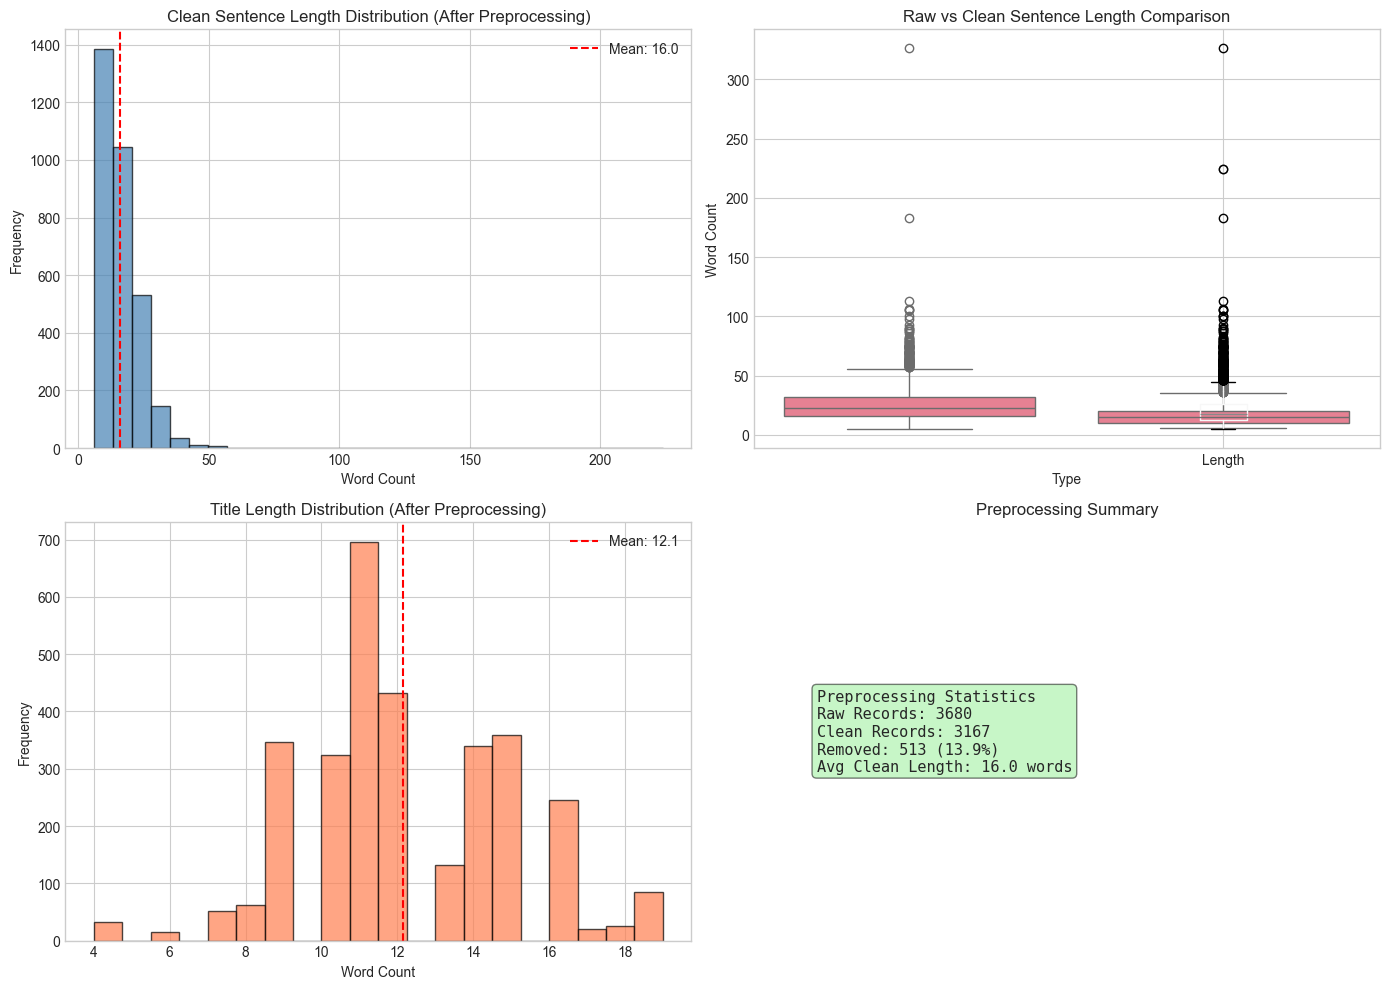

Saved: charts/after_preprocessing_analysis.png


In [39]:
# Data Visualization: After Preprocessing
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Load preprocessed data
df_clean = pd.read_csv('clean_news.csv')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Clean sentence length distribution
df_clean['clean_length'] = df_clean['clean_sentence'].apply(lambda x: len(str(x).split()) if pd.notna(x) else 0)
axes[0, 0].hist(df_clean['clean_length'], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 0].axvline(df_clean['clean_length'].mean(), color='red', linestyle='--', label='Mean: ' + str(round(df_clean['clean_length'].mean(), 1)))
axes[0, 0].set_xlabel('Word Count')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Clean Sentence Length Distribution (After Preprocessing)')
axes[0, 0].legend()

# 2. Sentence length comparison (before vs after)
df_raw = pd.read_csv('Day1_Crawl/ket_qua_sentence.csv')
df_raw['raw_length'] = df_raw['Sentence'].apply(lambda x: len(str(x).split()))
comparison_data = pd.concat([
    pd.DataFrame({'Length': df_raw['raw_length'], 'Type': 'Raw'}),
    pd.DataFrame({'Length': df_clean['clean_length'], 'Type': 'Clean'})
])

sns.boxplot(data=comparison_data, x='Type', y='Length', ax=axes[0, 1])
axes[0, 1].set_title('Raw vs Clean Sentence Length Comparison')
comparison_data.boxplot(ax=axes[0, 1])
axes[0, 1].set_ylabel('Word Count')
axes[0, 1].set_title('Raw vs Clean Sentence Length Comparison')

# 3. Title length in cleaned data
df_clean['title_length'] = df_clean['Title'].apply(lambda x: len(str(x).split()))
axes[1, 0].hist(df_clean['title_length'], bins=20, edgecolor='black', alpha=0.7, color='coral')
axes[1, 0].axvline(df_clean['title_length'].mean(), color='red', linestyle='--', label='Mean: ' + str(round(df_clean['title_length'].mean(), 1)))
axes[1, 0].set_xlabel('Word Count')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Title Length Distribution (After Preprocessing)')
axes[1, 0].legend()

# 4. Preprocessing stats
raw_count = len(df_raw)
clean_count = len(df_clean)
removed = raw_count - clean_count
stats_text = (
    "Preprocessing Statistics\n"
    "Raw Records: " + str(raw_count) + "\n"
    "Clean Records: " + str(clean_count) + "\n"
    "Removed: " + str(removed) + " (" + str(round(removed/raw_count*100, 1)) + "%)\n"
    "Avg Clean Length: " + str(round(df_clean['clean_length'].mean(), 1)) + " words"
)
axes[1, 1].text(0.1, 0.5, stats_text, fontsize=11, family='monospace', verticalalignment='center', bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))
axes[1, 1].axis('off')
axes[1, 1].set_title('Preprocessing Summary')

plt.tight_layout()
plt.savefig('charts/after_preprocessing_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: charts/after_preprocessing_analysis.png')

---

# Step 3: NER Encoding (Day3)

Using spaCy for NER labeling:
- Load spaCy model
- Extract entities (PERSON, ORG, GPE, DATE, etc.)
- Apply rule-based corrections
- Encode tokens and labels

In [93]:
import sys
import subprocess

def run_cmd(cmd):
    print("Running:", " ".join(cmd))
    result = subprocess.run(cmd, capture_output=True, text=True)
    print(result.stdout)
    if result.returncode != 0:
        print(result.stderr)
        raise RuntimeError("Command failed")

# Cài spaCy vào đúng Python interpreter của notebook
run_cmd([sys.executable, "-m", "pip", "install", "-q", "spacy"])

# Tải model en_core_web_sm
run_cmd([sys.executable, "-m", "spacy", "download", "en_core_web_sm"])

Running: c:\Users\pc\AppData\Local\Programs\Python\Python313\python.exe -m pip install -q spacy

Running: c:\Users\pc\AppData\Local\Programs\Python\Python313\python.exe -m spacy download en_core_web_sm
  Using cached https://github.com/explosion/spacy-models/releases/download/en_core_web_sm-3.8.0/en_core_web_sm-3.8.0-py3-none-any.whl (12.8 MB)
âœ” Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')



In [9]:
import pandas as pd
import spacy
import numpy as np
import pickle
import re

# Load spaCy model
nlp = spacy.load("en_core_web_sm")

# Read dataset
df = pd.read_csv("clean_news.csv")
sentences = df["clean_sentence"].dropna().tolist()

print(f"Total sentences: {len(sentences)}")

Total sentences: 3167


In [10]:
# Metrics
def compute_metrics(p):
    from seqeval.metrics import classification_report
    
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)

    true_predictions = []
    true_labels = []
    
    for pred, label in zip(predictions, labels):
        temp_pred = []
        temp_label = []
        for pred_id, label_id in zip(pred, label):
            if label_id != -100:
                temp_pred.append(id2label[int(pred_id)])
                temp_label.append(id2label[int(label_id)])
        if temp_pred:
            true_predictions.append(temp_pred)
            true_labels.append(temp_label)

    report = classification_report(true_labels, true_predictions, digits=4)
    print("\n" + report)
    return {}

In [ ]:
# NER labeling process
dataset = []

for sentence in sentences:
    doc = nlp(sentence)

    tokens = [token.text for token in doc]
    labels = ["O"] * len(tokens)

    # Extract entities from spaCy
    for ent in doc.ents:
        start = ent.start
        end = ent.end
        label = ent.label_

        labels[start] = "B-" + label
        for i in range(start + 1, end):
            labels[i] = "I-" + label

    # Apply corrections
    labels = correct_entities(tokens, labels)

    dataset.append((tokens, labels))

# Show example
print("Example tokens + labels:")
for t, l in zip(dataset[0][0], dataset[0][1]):
    print(f"  {t:<15} {l}")

In [14]:
# Create vocabulary
token2id = {}
id2token = {}

idx = 1
for tokens, labels in dataset:
    for token in tokens:
        if token not in token2id:
            token2id[token] = idx
            id2token[idx] = token
            idx += 1

# Encode labels
label_set = set()
for tokens, labels in dataset:
    label_set.update(labels)

label2id = {label: i for i, label in enumerate(sorted(label_set))}
id2label = {i: label for label, i in label2id.items()}

print("Label set:", label2id)
print(f"Vocabulary size: {len(token2id)}")

Label set: {}
Vocabulary size: 0


In [12]:
# Encode dataset
encoded_dataset = []

for tokens, labels in dataset:
    token_ids = [token2id[token] for token in tokens]
    label_ids = [label2id[label] for label in labels]

    encoded_dataset.append({
        "tokens": token_ids,
        "labels": label_ids
    })

# Padding
MAX_LEN = 50

def pad(seq, max_len, pad_value=0):
    return seq[:max_len] + [pad_value] * (max_len - len(seq))

X = []
y = []

for item in encoded_dataset:
    X.append(pad(item["tokens"], MAX_LEN))
    y.append(pad(item["labels"], MAX_LEN))

X = np.array(X)
y = np.array(y)

print(f"Dataset shape: X={X.shape}, y={y.shape}")

Dataset shape: X=(0,), y=(0,)


In [15]:
# Save encoded dataset
with open("ner_dataset.pkl", "wb") as f:
    pickle.dump({
        "X": X,
        "y": y,
        "token2id": token2id,
        "label2id": label2id,
        "id2label": id2label
    }, f)

print("Saved dataset to ner_dataset.pkl")

Saved dataset to ner_dataset.pkl


---

# Step 4: Auto-Labeling with custom mapping (Day4)



In [100]:
{
'PERSON': [
    'Noem', 'Ana Reyes', 'Joe Biden', 'Reyes', 'Kristi Noem', 'Donald Trump', 'Tricia McLaughlin', 'McLaughlin',
    'Clintons', 'Bill', 'Hillary Clinton', 'Jeffrey Epstein', 'Bill Clinton', 'Mike Johnson', 'Johnson', 'Angel Urena',
    'James Comer', 'Comer', 'Elon Musk', 'Ali Javaheri', 'Jensen Huang', 'Sam Altman', 'Altman', 'Don Ho', 'Ho',
    'Kevin Beaumont', 'Alex Karp', 'Karp', 'Peter Thiel', 'Trump', 'JD Vance', 'Modi', 'Narendra Modi', 'Nayara',
    'Alex Pretti', 'Eric C. Tostrud', 'Mary Barra', 'Robert Friedland', 'Stephen Miller', 'Jack', 'Kanishka Singh',
    'Sergei Lavrov', 'Lavrov', 'Delcy Rodriguez', 'Laura Dogu', 'Jorge Rodriguez', 'Gil', 'Dogu', 'Marco Rubio',
    'Nicolas Maduro', 'Rodriguez', 'Peter Attia', 'Attia', 'Bari Weiss', 'Ayatollah Ali Khamenei', 'Khamenei',
    'Mirhossein Mousavi', 'Parisa Hafezi', 'Samia Nakhoul', 'William Maclean', 'Tommy Pigott', 'Pigott',
    'Cesar Andred Aguirre', 'Dania Mariela Escobar', 'Kumar Mangalam Birla', 'Shivangi Acharya', 'Manoj Kumar',
    'Philip Blenkinsop', 'Suzanne P. Clark', 'Clark', 'Piyush Goyal', 'Matt Schlicht', 'Schlicht', 'Ami Luttwak',
    'Luttwak', 'Jamieson O\'Reilly', 'O\'Reilly', 'Ladd Serwat', 'Clay Gaspar', 'Tom Jorden', 'Gaspar', 
    'Gabriele Sorbara', 'Andrew Dittmar', 'Jonas Gahr Stoere', 'Mette-Marit', 'Stoere', 'Marius', 'Haakon',
    'Marius Borg Hoiby', 'Todd Lyons', 'Vladimir Motin', 'Mark Pernia', 'Tom Little', 'Motin', 'Leonard',
    'Pernia', 'Little', 'Mark Angelo Pernia', 'Sturla Henriksboe', 'Henriksboe', 'Ellen Holager Andenaes',
    'Son Heung-min', 'Terence McManus', 'Michael Leuchten', 'Albert Bourla', 'Evan Seigerman', 'Michael Nedelcovych',
    'Karen Andersen', 'Markus Manns', 'Hugh Johnston', 'Bob Iger', 'Josh D\'Amaro', 'Jessica Reif Ehrlich', 'Iger',
    'Larry Ellison', 'Rafael Sotomayor', 'Jens-Frederik Nielsen', 'Nielsen', 'Doug Burgum', 'Abdourahamane Tiani',
    'Mohamed Hamdan Dagalo', 'Dagalo', 'Samir Farag', 'Farag', 'Jeremy Binnie', 'Wim Zwijnenburg', 'Hakan Fidan',
    'Justin Lynch', 'Jalel Harchaoui', 'Volodymyr Zelenskiy', 'Zelenskiy', 'Mark Rutte', 'Oleksiy Kuleba',
    'Ihor Terekhov', 'Denys Shmyhal', 'Natalia Hlobenko', 'Hlobenko', 'Maxim Timchenko', 'Kevin Warsh', 'Warsh',
    'Jim Ferraioli', 'David Morrison', 'Zavier Wong', 'Adam McCarthy', 'Sahak Manuelian', 'Giovanni Staunovo',
    'Tai Wong', 'Steve Witkoff', 'Witkoff', 'Peter Mandelson', 'Mandelson', 'Ella Marriott', 'Sanae Takaichi',
    'Takaichi', 'Takeshi Yamaguchi', 'Savannah Guthrie', 'Nancy Guthrie', 'Chris Nanos', 'Nanos', 'Fidel Castro',
    'Bruno Rodríguez', 'Anne Boleyn', 'Henry VIII', 'Elizabeth I', 'Owen Emmerson', 'Elizabeth', 'Anne',
    'Helene Harrison', 'Nicholas Sanders', 'Harrison', 'Kate McCaffrey', 'Ian Tyers', 'Alistair Darling',
    'Geoffrey Robinson', 'Reinaldo Avila da Silva', 'Nick Butler', 'Chris Wormald', 'Morgan McSweeney',
    'Wes Streeting', 'Robert Maxwell', 'Ghislaine Maxwell', 'Lynn Forester de Rothschild', 'Evelyn', 'Reinaldo',
    'Darren Jones', 'Emily Maitlis', 'Gaby Hinsliff', 'Zoe Williams', 'Polly Toynbee', 'Rafael Behr', 'Keir Starmer',
    'Harvey Weinstein', 'Weinstein', 'Leon Black', 'Black', 'Susan Estrich', 'Maria Farmer', 'Annie', 'Jean-Luc Brunel',
    'Brunel', 'Virginia Giuffre', 'Maxwell', 'Andrew Mountbatten-Windsor', 'Giuffre', 'Sigrid McCawley',
    'Jennifer Freeman', 'Spencer Kuvin', 'David Copperfield', 'Copperfield', 'Lacey Carroll', 'Oprah', 'Villafaña',
    'Susie Roe', 'Roe', 'Becky Roe', 'Susan Roe', 'Marty Baron', 'Nate Silver', 'Silver', 'Sarah Ferguson', 'Sarah',
    'Fergie', 'Mike Sitrick', 'Beatrice', 'Eugenie', 'Glenn Dubin', 'Billie Eilish', 'Kehlani', 'Olivia Dean',
    'Bad Bunny', 'Benito Ocasio', 'Mark Ruffalo', 'Wanda Sykes', 'Sade', 'Amy Winehouse', 'Adele', 'Dua Lipa',
    'Addison Rae', 'Sombr', 'Leon Thomas', 'Ludwig Göransson', 'Henry Walter', 'Greg Kurstin', 'Max Martin',
    'Jack Antonoff', 'Katy Perry', 'Rihanna', 'Miley Cyrus', 'Charli xcx', 'Axel Disasi', 'Nuno Espírito Santo',
    'Jean-Clair Todibo', 'Max Kilman', 'Mamadou Sarr', 'Liam Rosenior', 'Aaron Anselmino', 'David Datro Fofana',
    'Jérémy Jacquet', 'Tyrique George', 'Enzo Maresca', 'Jack Grealish', 'David Moyes', 'Dwight McNeil',
    'Cristian Romero', 'Joel Mvuka', 'Ryan Naderi', 'Evan Mooney', 'Viktor Gyökeres', 'Ben Fisher', 'Joe Aribo',
    'Jamaal Lascelles', 'Divine Mukasa', 'Madiodio Dia', 'John Mousinho', 'Gustavo Caballero', 'Leighton Clarkson',
    'Noah Eile', 'Tomi Horvat', 'Anis Mehmeti', 'Zak Vyner', 'Andy Hunter', 'Angel Gomes', 'Cyle Larin',
    'Junior Hoilett', 'Rob Edwards', 'Wayne Rooney', 'Wes Harding', 'Alex Reid', 'Karim Benzema', 'Kalvin Phillips',
    'Nilson Angulo', 'Ryan Hardie', 'Dennis Geiger', 'Andrew Moran', 'Saba Goglichidze', 'Javi Gracia', 'Joe Rothwell',
    'James Wilson', 'Ange Postecoglou', 'Simon Adingra', 'Luca Netz', 'Julian Mentz', 'Junior Adamu', 'Johnny Kenny',
    'Marvelous Nakamba', 'Gabriele Biancheri', 'Arne Engels', 'Rodri', 'Dominic Solanke', 'Arsène Wenger',
    'Yannick Woudstra', 'Maro Itoje', 'Jamie George', 'Henry Arundell', 'Tommy Freeman', 'Florence', 'Genge',
    'Ellis Genge', 'George Ford', 'Tom Roebuck', 'Samuel López', 'Jannik Sinner', 'Daniil Medvedev', 'Rafael Nadal',
    'Roger Federer', 'Elena Rybakina', 'Júnior Pena', 'Eustáquio da Silva Pena Júnior', 'Lula da Silva', 'Jair Bolsonaro',
    'Andrew Lattarulo', 'Wael Tarabishi', 'Maher', 'Wael', 'Shahd Arnaout', 'Ali Elhorr', 'Joanna Cuevas Ingram',
    'Baher Azmy', 'Hakeem Jeffries', 'Ro Khanna', 'Thomas Massie', 'Pam Bondi', 'Jamie Raskin', 'Kemi Badenoch',
    'Faisal Islam', 'Nick Macpherson', 'Jeff Bezos', 'Will Lewis', 'Edward Snowden', 'Jason Rezaian', 'Mehdi Mahmoudian',
    'Ali Khamenei', 'Vida Rabbani', 'Abdullah Momeni', 'Jafar Panahi', 'Matthew Michelsen', 'Chris Vanek', 'Eddie Vasquez',
    'Mahmud Azem', 'Amichai Eliyahu', 'Wala ’ a Ghazal', 'Mahmud Ghazal', 'Thorbjørn Jagland', 'Tymur Tkachenko',
    'Masoud Pezeshkian', 'Abbas Araghchi', 'Sarah Breeden', 'Rebecca Jackson', 'Raphael Bostic', 'Fritz Emmanuel Lesly Miot',
    'Rudolph Civil', 'Marlene Gail Noble', 'Marica Merline Laguerre', 'Vilbrun Dorsainvil', 'Margaret Baum',
    'Ender Perea', 'Jose Luis Galindo', 'Lin Jian', 'Teeranan Nandhakwang', 'Touch Sokhak', 'Shahid Rind', 'Sarfraz Bugti',
    'Bakht Muhammad Kakar', 'Joe Abate', 'David Beckworth', 'Scott Anderson', 'Marc Jones', 'Wayne Cole', 'Sonali Paul',
    'Moustafa Abdel Hadi', 'Giovanni Staunovo', 'Tony Sycamore', 'Vivek Dhar', 'Nawar Rahawi', 'Noah Bonsey', 'Tim Ghriskey',
    'Michael Hsueh', 'John Meyer'
],
'ORG': [
    'Reuters', 'U . S . Department of Homeland Security', 'Department of Homeland Security', 'Haiti\'s',
    'Homeland Security', 'TPS', 'United States', 'Congress', 'xAI', 'SpaceX', 'Alphabet', 'Google', 'Meta',
    'Amazon', 'Anthropic', 'OpenAI', 'LSEG', 'Wall Street Journal', 'Neuralink', 'Boring Company', 'Starlink',
    'PitchBook', 'NASA', 'Department of Defense', 'New York Times', 'Verge', 'Nvidia', 'AMD', 'Cerebras', 'Groq',
    'ChatGPT', 'Codex', 'TPUs', 'MarketWatch', 'Barron s', 'Trent University', 'Yahoo Finance', 'NHTSA',
    'Waymo', 'Dragoneer Investment Group', 'DST Global', 'Sequoia Capital', 'Mubadala Capital', 'Andreessen Horowitz',
    'T . Rowe Price', 'Tracxn', 'Tesla', 'Zoox', 'UNICEF', 'House Oversight Committee', 'US DOJ', 'House',
    'House of Representatives', 'U . S . Justice Department', 'Black Lives Matter', 'NATO', 'Supreme Court',
    'Palantir Technologies', 'Palantir', 'ICE', 'CapGemini', 'CIA', 'Senate', 'Air Force One', 'Truth Social',
    'Indian Oil Corp', 'Bharat Petroleum Corp', 'Nayara Energy', 'Reliance Industries', 'PDVSA', 'European Union',
    'Bitfinex', 'Charles Schwab', 'Microsoft', 'Azure', 'American Banker', 'Federal Reserve', 'Notepad++',
    'Cybersecurity and Infrastructure Security Agency', 'Rapid7', 'Lotus Blossom', 'BCA', 'Hennepin County Attorney ’ s Office',
    'DHS', 'Dominion Voting Systems', 'Fox News', 'Foreign Ministry', 'National Assembly', 'National Immigration Law Center',
    'State Department', 'Aditya Birla Group', 'Reserve Bank of India', 'Chamber of Commerce', 'U.S.-India Business Council',
    'G7', 'HMRC', 'Institute for Supply Management', 'FHN Financial', 'BMO Capital Markets', 'EXIM Bank',
    'MP Materials', 'USA Rare Earth Inc', 'General Motors', 'Hartree Partners', 'Traxys North America',
    'Mercuria Energy Group', 'Costco', 'University of Maine', 'Columbia Journalism School', 'Islamic State',
    'SITE Intelligence Group', 'ACLED', 'ISWAP', 'ASKY Airlines', 'Air Cote d\'Ivoire', 'Devon Energy',
    'Coterra Energy', 'Diamondback', 'Endeavor Energy Resources', 'Siebert Williams Shank & Co.', 'Kimmeridge',
    'Enverus Intelligence Research', 'Security Council', 'Norstat', 'NRK', 'J.P. Morgan', 'JP Morgan', 'CME Group',
    'Commonwealth Bank of Australia', 'CBA', 'TrendForce', 'Equinor', 'Vista Energy', 'Verdi', 'Deutsche Bahn',
    'S-Bahn', 'City Index', 'FOREX.com', 'Met', 'HSTS', 'Boervolk of the Orange Free State', 'Orania', 'U.N.',
    'Kalameh', 'Moltbook', 'Wiz', 'OpenClaw', 'Clawdbot', 'Moltbot', 'Vall d\'Hebron', 'Health Ministry',
    'Nezopont Institute', 'Publicus Institute', 'Mi Hazank', 'Fidesz', 'Tisza', 'Ant International', 'Alipay+',
    'NPCI', 'Exxon Mobil', 'ConocoPhillips', 'ISIS', 'Board of Peace', 'SPR', 'Vulcan Elements', 'Infosys',
    'Wipro', 'HDFC Bank', 'iShares MSCI India', 'World Trade Organization', 'Emkay Global', 'Uefa', 'Saja Boys',
    'Huntr/x', 'FKA twigs', 'Recording Academy', 'Netflix', 'RB Leipzig', 'Burnley', 'West Ham', 'Chelsea',
    'Aston Villa', 'Southampton', 'Bournemouth', 'Tottenham', 'Rennes', 'Liverpool', 'Bayern Munich', 'St Mirren',
    'Santos', 'Bristol City', 'Crystal Palace', 'Sturm Graz', 'Ipswich', 'Wrexham', 'Marseille', 'Hibernian',
    'Swindon Town', 'Millwall', 'Plymouth', 'Udinese', 'Huddersfield', 'Aberdeen', 'Bolton', 'Luton Town',
    'Rotherham', 'Al-Hilal', 'Al-Ahli', 'Al-Ittihad', 'PIF', 'Al-Riyadh', 'Quilter Cheviot', 'LDP',
    'Liberal Democratic Party', 'AJ Bell', 'BMO', 'Citizens for Responsibility and Ethics in Washington',
    'Aryam Investment', 'World Liberty Financial', 'Binance', 'MGX', 'Marsh Law', 'Boies Schiller Flexner',
    'Goldlaw', 'Guardian', 'MGM Grand Hollywood Theater', 'Harbottle & Lewis', 'Carter Ruck', 'Wayback Machine',
    'Emek Shaveh', 'Otzma Yehudit', 'City of David Foundation', 'Elad', 'Unesco', 'Al-Aqsa Martyrs Hospital',
    'FPA', 'SNP', 'Reform UK', 'Foreign Press Association', 'BBC', 'Global Counsel', 'Privy Council', 'NLGJA',
    'State Information Service', 'DTEK', 'Vantor', 'CBOE', 'NXP Semiconductors', 'Boeing', 'Gothams LLC',
    'Gothams', 'Planned Parenthood Great Rivers', 'Morena', 'MSCI', 'CBA \' s', 'Vanguard', 'Cerulli Associates',
    'Morningstar', 'TrendForce', 'TrendForce', 'TrendForce', 'TrendForce', 'TrendForce', 'TrendForce', 'TrendForce'
],
'GPE': [
    'U . S .', 'Washington', 'D . C .', 'Haiti', 'United States', 'New York', 'Florida', 'China', 'India', 'Kyiv',
    'Russia', 'Ukraine', 'San Francisco', 'Germany', 'USA', 'Venezuela', 'Minnesota', 'Frankfurt', 'Canada',
    'Pakistan', 'Afghanistan', 'Italy', 'France', 'Belgium', 'Portugal', 'Netherlands', 'Norway', 'Sweden',
    'Denmark', 'Spain', 'Honduras', 'Nicaragua', 'Nepal', 'Cameroon', 'Somalia', 'Eritrea', 'Brazil', 'Uruguay',
    'Bosnia', 'Albania', 'Bangladesh', 'Taiwan', 'Israel', 'Japan', 'Mexico', 'South Korea', 'Argentina',
    'Turkey', 'Egypt', 'Sudan', 'Libya', 'Qatar', 'Saudi Arabia', 'UAE', 'Ivory Coast', 'Benin', 'Mali',
    'Burkina Faso', 'Jordan', 'Guatemala', 'South Sudan', 'Iraq', 'Lebanon', 'Gaza', 'UK', 'Singapore', 'Britain',
    'Surin', 'Taizhou', 'Luebeck', 'Nuremberg', 'Stuttgart', 'Karlsruhe', 'Freiburg', 'Hamburg', 'Bremen', 'Munich',
    'Istanbul', 'Dnipropetrovsk', 'Zaporizhzhia', 'Kharkiv', 'Donetsk', 'Izium', 'Balakliia', 'Sumy', 'Abu Dhabi',
    'Tirana', 'Lhasa', 'Dharamshala', 'Nuuk', 'Lagos', 'Murcia', 'El Palmar', 'Moscow', 'Oslo', 'Saint Paul',
    'Texas', 'New Mexico', 'Oklahoma', 'Maine', 'Boston', 'Tucson', 'Arizona', 'Michigan', 'Montana', 'Nevada',
    'Ohio', 'Darfur', 'al-Fashir', 'Nyala', 'Hainan', 'Corfu', 'Gorton', 'Denton', 'Hartlepool', 'Foy', 'Porchester',
    'Barcelona', 'Houston', 'Rhode Island', 'Providence', 'Oklahoma City', 'Murcia', 'El Palmar', 'St Petersburg'
],
'LOC': [
    'Strait of Hormuz', 'Arabian Sea', 'Caribbean', 'Arctic', 'Permian Basin', 'Delaware Basin', 'Anadarko Basin',
    'Silicon Valley', 'Gulf', 'Middle East', 'Africa', 'Southeast Asia', 'Central America', 'South America',
    'West Bank', 'East Jerusalem', 'Jerusalem', 'Vaca Muerta', 'Sahel', 'Lake Chad', 'Nile River', 'Gaza Strip',
    'Mediterranean', 'Capitol', 'Potomac River', 'Selhurst Park', 'London Stadium', 'Etihad Stadium',
    'Allianz Stadium', 'Stamford Bridge', 'Old City', 'Central Park', 'Musha Cay', 'Palm Beach', 'Hever',
    'East Oweinat', 'Ain al-Arab', 'Kobani', 'Nyala', 'al-Fashir', 'East Asia', 'Lake Chad basin'
],
'NORP': [
    'nonwhite', 'Haitians', 'Haitian', 'Democratic', 'Republican', 'Democrats', 'Republicans', 'Russian', 'Ukrainian',
    'Chinese', 'British', 'French', 'Indian', 'European', 'Western', 'Arab', 'Afghan', 'Islamic', 'jihadist',
    'Kurdish', 'Tibetan', 'Buddhist', 'Alawites', 'Druze', 'Inuit', 'Afrikaners', 'Dutch', 'Zulu', 'Brazilian',
    'Venezuelan', 'Pakistani', 'Salvadoran', 'Emirati', 'Slovenian', 'Paraguayan', 'Ecuador', 'Finnish', 'Swedish',
    'Danish', 'Norwegian', 'Australian', 'American', 'Canadian', 'Asian', 'Latin American', 'Balkan', 'South Asian',
    'Caribbean', 'African', 'Black', 'white', 'KPop', 'English', 'Catholic', 'Anglican', 'Boervolk', 'Scandis',
    'Maya', 'Quetta', 'Baloch', 'Taliban', 'Al-Nassr', 'Al-Ahli', 'Al-Ittihad', 'Al-Hilal', 'RB Leipzig',
    'Eintracht', 'Sturm Graz', 'LDP', 'Ishin', 'Morena', 'Portuguese', 'Hebrew', 'Asayish'
],
'PRODUCT': [
    'Grok', 'ChatGPT', 'Azure', 'Notepad++', 'Model Y', 'Model 3', 'Model S', 'Model X', 'DRAM', 'GE9X', '777X',
    'Akinci', 'Bayraktar', 'UAV', 'Airbus A319', 'LPG', 'Ether', 'Bitcoin', 'GNX', 'Wegovy', 'Zepbound', 'Ozempic',
    'GPUs', 'TPUs', 'SRAM', 'Solong', 'Stena Immaculate', 'Chrysopigi Lady', 'Yuanbao', 'Qwen', 'OpenClaw', 'Clawd',
    'Clawdbot', 'Moltbot', 'iOS', 'Android', 'Windows'
],
'WORK_OF_ART': [
    'Constitution\'s', 'Fifth Amendment', 'Pulitzer Prize', 'It Was Just an Accident', 'Palme d ’ Or', 'Oscars',
    'Academy Awards', 'The Art of Loving', 'Meditations', 'Outlive', 'Oro Rojo', '60 Minutes', 'Hamilton',
    'Moulin Rouge', 'Mrs. Doubtfire', 'The Outsiders', 'Zootopia 2', 'Avatar : Fire and Ash', 'Lincoln',
    'Capturing a Queen', 'Rose', 'The Dan Bongino Show', 'Vanity Fair', 'Wall Street Journal', 'Evening Standard',
    '60 Minutes', 'Outlive : The Science and Art of Longevity', 'The Many Faces of Anne Boleyn', 'Wicked',
    'Without Further Ado , Vol One', 'Songs of a Lost World', 'Wish', 'Bloodflowers'
],
'DATE': [
    'Wednesday', 'Feb 2', 'Monday', '2016', 'July 2024', 'February 3 , 2026', 'February 2025', 'August',
    'November', 'October', 'July', '2010', '2024', 'last week', 'early 2000s', '2021', '2019', '2000',
    'September', 'January 30', 'January', '2023', 'Dec 2', 'June 2025', 'September 2 , 2025', 'December 2 , 2025',
    'January 21', 'April 9 , 2025', 'August 27 , 2025', 'January 27 , 2026', 'last year', 'Feb 3', 'Tuesday',
    'Sunday', 'Thursday', 'Saturday', 'midterm', '2022', '17th century', '1840', '20th century', '1910', '1994',
    '1837', '2027', 'January 23', 'December 27', 'February 13 , 2025', 'April', 'mid-2025', 'April 10', 'July 31',
    'August 7', 'June', 'March', 'April 12', '1983', '1979', '2008', '2007', '2011', '2014', '2013', '2012',
    '2015', '2018', '2020', '2004', '2005', '1993', '1992', '1980s', '1970s', '1990s', '1391', '1536',
    'February 15', 'Lunar New Year', 'Valentine ’ s Day', 'Christmas', 'January 24', 'June 3', 'January 21-24',
    'January 26-27', 'February 6', 'August 27', 'May 9 2010', '26 January 2021', 'July 4', '250th anniversary',
    'September 29', 'December 28', 'January 9', 'September 2010', '11 September 2013', 'April 2003', 'May 2024',
    'October 2024', 'February 2024', 'March 2025', 'September 2025', 'August 2025', 'January 15', 'October 2010'
],
'MONEY': [
    '250 billion', '1 trillion', '203 billion', '800 billion', '230 billion', '1.5 trillion', '100 billion',
    '20 billion', '14 billion', '570 million', '1 . 41 billion', '30 million', '12 billion', '10 billion',
    '1.1 billion', '21.4 billion', '700 million', '5 billion', '250 million', '350 million', '431 million',
    '3 billion yuan', '1 billion yuan', '500 million yuan', '20,000 pounds', '2 billion', '45 billion',
    '50 billion', '300 billion', '40 million', '£55m', '£5m', '£22m', '£20m', '£15m', '£2.5m', '£1m', '£3m',
    '£9m', '£34.6m', '£13m', '£35m', '£30m', '£26m', '£21.5m', '£100m', '£12m', '$ 500bn', '$ 5,594.82',
    '$ 4,700', '$ 900', '$ 6,200/oz', '$ 6,300/oz', '$ 6,000', '$ 5,000', '$ 1,000', '$ 149', '$ 299',
    '$ 121.64', '$ 76.81', '$ 25,000', '$ 75,000', '£10,000', '£3,250', '£20bn', '€500bn', '$ 36 million',
    '$ 187m', '$ 31m', '$ 70bn', '$ 40m', '$ 578m', '$ 144', '$ 3.05 billion', '$ 3.25 billion', '$ 3.10 billion',
    '$ 3.34 billion', '$ 3.31 billion', '$ 3.35', '$ 3.27', '£16bn', '£3.74m', '£870k', '$ 787 million',
    '$ 10bn', '$ 1.67bn', '140,000 won', '$ 97', '$ 12bn'
],
'QUANTITY': [
    '7 . 0 magnitude', '18 months', '6 million', '3.3 million', '60 km', '37 miles', '18 miles per hour',
    '29 kph', '400 kg', '3.5 kg', '7.72 pounds', '1.2 million barrels', '800,000 bpd', '20 Celsius',
    '4 Fahrenheit', '250-foot', '76-meter', '220,000 barrels', '50 million barrels', '1.2m barrels',
    '10 %', '120 billion', '130 billion', '158 billion', '105 billion', '134 billion', '126 billion',
    '182 hectares', '450 acres', '40 million barrels', '847,000 bpd', '867,000 bpd', '284,000 bpd',
    '220,000 bpd', '99,000 bpd', '156,000 bpd', '392,000 bpd', '400,000 barrel per day', '1.6 million barrels',
    '1 million bpd', '800,000 bpd', '394,000 barrels per day', '8.26 million barrels', '41.72 million barrels',
    '46.25 million barrels', '10 million barrels'
],
'CARDINAL': [
    '350 , 000', '1 . 4 million', '0 . 1433', '104 , 782 . 88', '126 , 000', '78 , 396', '1 , 142', 
    '270 , 000', '20.1 billion', '19.4 billion', '527', '871', '16,000', '3,000', '1,700', '3 million', 
    '6 million', '3.5m', '6m', '10', '12', '15', '16', '18', '20', '25', '26', '30', '35', '38', '39', 
    '40', '41', '43', '46', '50', '53', '60', '70', '75', '80', '84', '88', '90', '92', '100', '109', 
    '115', '129', '133', '150', '160', '167', '200', '217', '218-213', '233', '465', '700', '961',
    '125 to 150', '30', '11', '800', '3.14 billion', '1.63', '1.57', '110 million', '450 million',
    '100 million', '2.77', '3.17', '2.97', '2.90', '16', '2.8 %', '166.67', '0.34 %', '49,240.99',
    '58.63', '0.84 %', '6,917.81', '336.92', '1.43 %', '23,255.19', '0.16', '0.02 %', '1,043.93',
    '1.03 %', '2.2 %', '3.3 %', '1.72 %', '1.07', '63.21', '67.33', '1.55 %', '1.03', '6.14 %',
    '4,951.72', '7.58 %', '85.42', '1.08 %', '0.7022', '3.85 %', '4.268 %', '4.277 %', '1.1', '4.8983',
    '0.2', '3.572 %', '3.57 %', '426', '6,300', '10,000', '1,030', '29', '38', '961', '500,000',
    '187m', '31m', '17', '15.7 million', '720 million', '68,000', '10.1 %', '0.7 %'
],
'ORDINAL': ['Fifth', 'first', 'second', 'third', 'fourth', '14th', '90th', '250th', '11th'],
'TIME': [
    'Monday night', 'Saturday night', 'Sunday afternoon', '11pm', '8pm', '9pm', '19:00', '17:00', '21:00',
    '1600ish', 'midnight', 'early morning', 'late afternoon', '0450 GMT', 'nightfall', 'afternoon'
],
'LANGUAGE': ['Kanuri', 'Portuguese', 'Hebrew', 'French', 'English', 'Spanish'],
'FAC': [
    'White House', 'Oval Office', 'East Wing', 'Miraflores presidential palace', 'Buckingham Palace',
    'Royal Lodge', 'Tower of London', 'Old Bailey', 'Stamford Bridge', 'London Stadium', 'Etihad Stadium',
    'Allianz Stadium', 'Selhurst Park', 'Musha Cay', 'East Oweinat', 'Charles de Gaulle airport',
    'Niamey airport', 'Jose port', 'National Archives', 'MGM Grand Hollywood Theater', 'Al-Aqsa Martyrs Hospital'
]
}

{'PERSON': ['Noem',
  'Ana Reyes',
  'Joe Biden',
  'Reyes',
  'Kristi Noem',
  'Donald Trump',
  'Tricia McLaughlin',
  'McLaughlin',
  'Clintons',
  'Bill',
  'Hillary Clinton',
  'Jeffrey Epstein',
  'Bill Clinton',
  'Mike Johnson',
  'Johnson',
  'Angel Urena',
  'James Comer',
  'Comer',
  'Elon Musk',
  'Ali Javaheri',
  'Jensen Huang',
  'Sam Altman',
  'Altman',
  'Don Ho',
  'Ho',
  'Kevin Beaumont',
  'Alex Karp',
  'Karp',
  'Peter Thiel',
  'Trump',
  'JD Vance',
  'Modi',
  'Narendra Modi',
  'Nayara',
  'Alex Pretti',
  'Eric C. Tostrud',
  'Mary Barra',
  'Robert Friedland',
  'Stephen Miller',
  'Jack',
  'Kanishka Singh',
  'Sergei Lavrov',
  'Lavrov',
  'Delcy Rodriguez',
  'Laura Dogu',
  'Jorge Rodriguez',
  'Gil',
  'Dogu',
  'Marco Rubio',
  'Nicolas Maduro',
  'Rodriguez',
  'Peter Attia',
  'Attia',
  'Bari Weiss',
  'Ayatollah Ali Khamenei',
  'Khamenei',
  'Mirhossein Mousavi',
  'Parisa Hafezi',
  'Samia Nakhoul',
  'William Maclean',
  'Tommy Pigott',
  'Pi

In [16]:
# Step 4: Relabeling with Custom Mappings (Day4)
# Apply rule-based relabeling to improve entity accuracy

import json
import csv
import ast
import re

def normalize_token(token):
    """Normalize token by removing unicode chars and punctuation"""
    token = re.sub(r'[\u200b\u2060\u200c\u200d\u00a0]', '', token)
    token = token.strip('.,;:!?()[]{}\'"-')
    return token.lower().strip()

def load_entity_mappings(json_path):
    """Load entity mappings from data.json"""
    with open(json_path, 'r', encoding='utf-8') as f:
        content = f.read()
        data = ast.literal_eval(content)

    entity_map = {}
    multi_word_map = {}

    for entity_type, entities in data.items():
        for entity in entities:
            entity_normalized = entity.lower().strip()
            entity_map[entity_normalized] = entity_type

            words = entity_normalized.split()
            if len(words) >= 2:
                if words[0] not in multi_word_map:
                    multi_word_map[words[0]] = []
                multi_word_map[words[0]].append({
                    'phrase': entity_normalized,
                    'type': entity_type,
                    'words': words
                })

    return entity_map, multi_word_map

def relabel_data(csv_path, entity_map, multi_word_map, output_path):
    """Relabel tokens using custom entity mappings"""
    results = []

    with open(csv_path, 'r', encoding='utf-8', newline='') as f:
        reader = csv.DictReader(f)

        for row in reader:
            tokens = ast.literal_eval(row['tokens'])
            labels = ast.literal_eval(row['labels'])

            new_labels = []
            i = 0
            while i < len(tokens):
                token = tokens[i]
                token_lower = normalize_token(token)
                original_label = labels[i]

                # Check for multi-word phrase matches first
                if token_lower in multi_word_map:
                    matched = False
                    for phrase_info in multi_word_map[token_lower]:
                        phrase_words = phrase_info['words']
                        phrase_len = len(phrase_words)

                        if i + phrase_len <= len(tokens):
                            remaining_tokens = [normalize_token(t) for t in tokens[i:i+phrase_len]]
                            if remaining_tokens == phrase_words:
                                for j in range(phrase_len):
                                    if j == 0:
                                        new_labels.append(f'B-{phrase_info["type"]}')
                                    else:
                                        new_labels.append(f'I-{phrase_info["type"]}')
                                i += phrase_len
                                matched = True
                                break
                    if matched:
                        continue

                # Check single token match
                if token_lower in entity_map:
                    entity_type = entity_map[token_lower]
                    if i > 0 and new_labels[i-1].endswith(f'-{entity_type}'):
                        new_labels.append(f'I-{entity_type}')
                    else:
                        new_labels.append(f'B-{entity_type}')
                else:
                    if i > 0 and new_labels[i-1].startswith('B-') and original_label.startswith('I-'):
                        prev_type = new_labels[i-1][2:]
                        new_labels.append(f'I-{prev_type}')
                    else:
                        new_labels.append(original_label)

                i += 1

            results.append({
                'tokens': tokens,
                'labels': new_labels
            })

    # Write results
    with open(output_path, 'w', encoding='utf-8', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=['tokens', 'labels'])
        writer.writeheader()
        for result in results:
            writer.writerow({'tokens': str(result['tokens']), 'labels': str(result['labels'])})

    return len(results)

# Run relabeling
print("Loading entity mappings from Day4.5_Relabeling/data.json...")
entity_map, multi_word_map = load_entity_mappings('Day4.5_Relabeling/data.json')
print(f"Loaded {len(entity_map)} single token mappings")
print(f"Loaded {len(multi_word_map)} multi-word phrase starting words")

print("\nRelabeling data (Day4.5)...")
count = relabel_data('manual_labeled.csv', entity_map, multi_word_map, 'relabeled_output.csv')
print(f"Relabeled {count} rows")
print(f"Output saved to: relabeled_output.csv")

Loading entity mappings from Day4.5_Relabeling/data.json...
Loaded 1342 single token mappings
Loaded 575 multi-word phrase starting words

Relabeling data (Day4.5)...
Relabeled 3113 rows
Output saved to: relabeled_output.csv


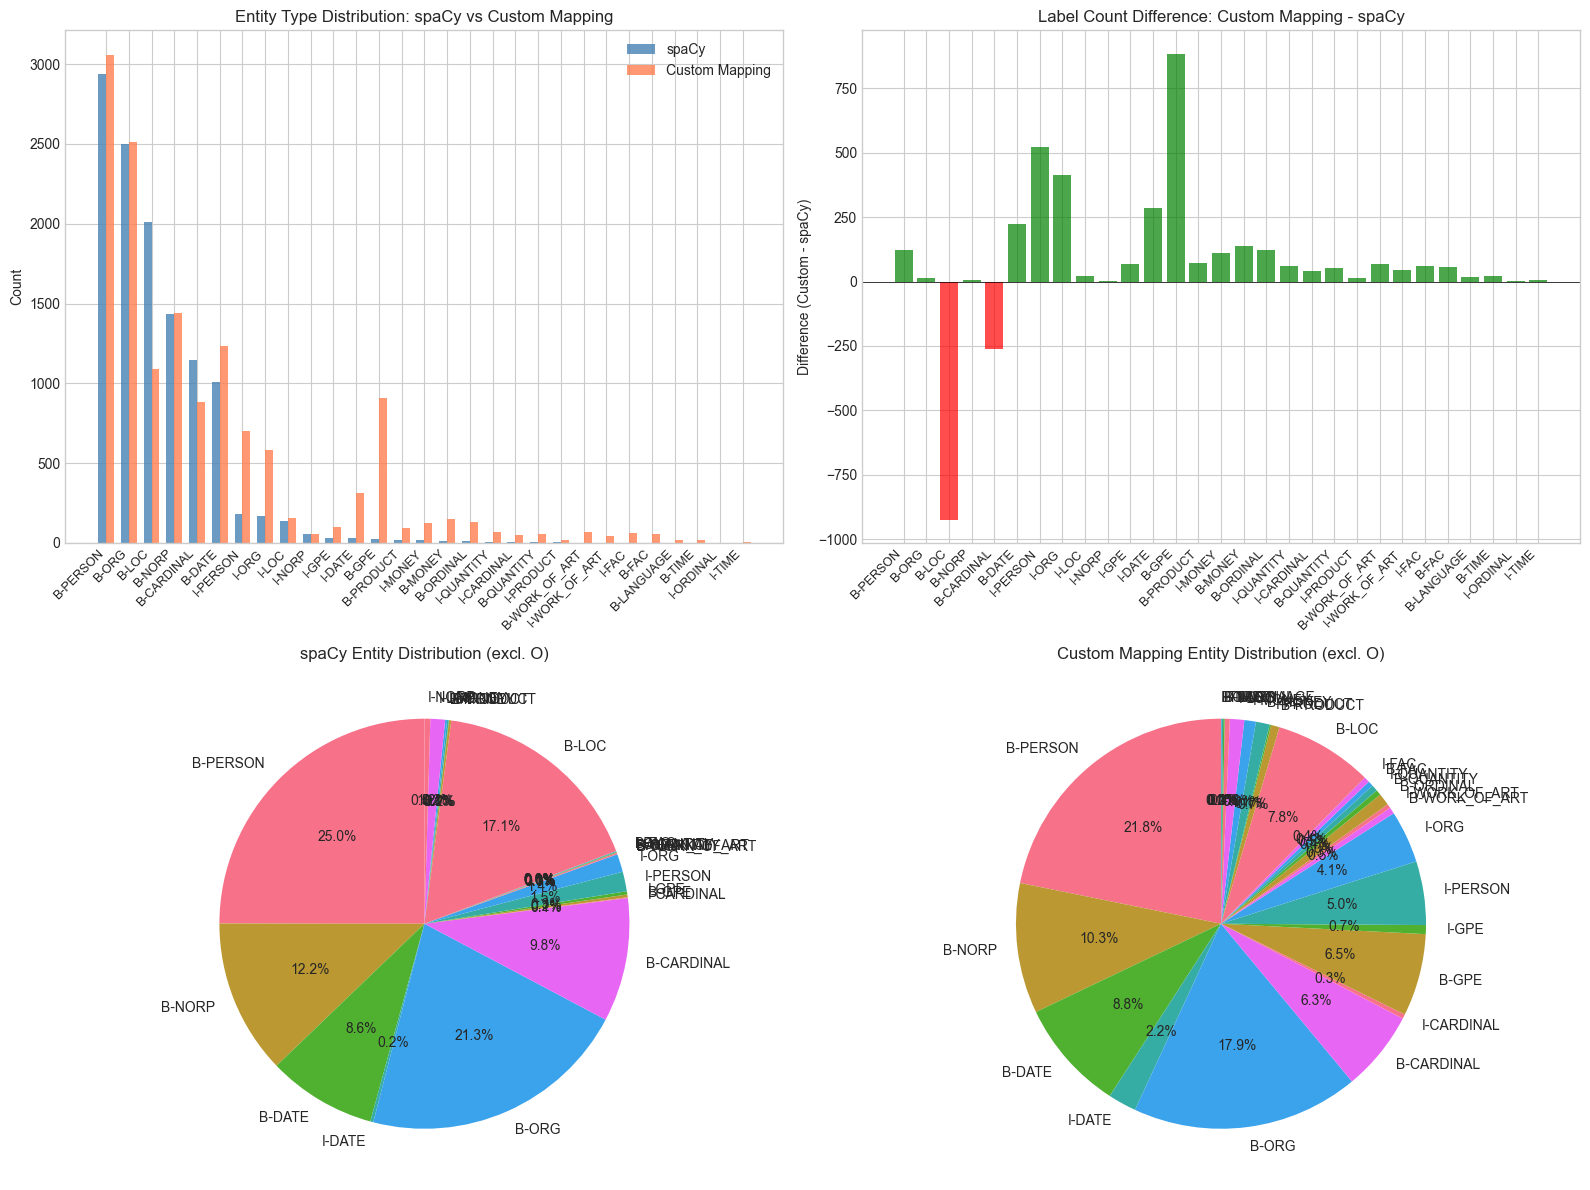


=== Label Comparison Summary ===
spaCy total labels: 97724
Custom Mapping total labels: 97724

spaCy unique entities: 25
Custom Mapping unique entities: 29

Saved: charts/spacy_vs_custom_mapping_comparison.png


In [38]:
# Visualization: spaCy vs Custom Mapping Labels Comparison
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import ast
from collections import Counter

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Load both datasets
df_spacy = pd.read_csv('Day4.5_Relabeling/manual_labeled.csv')  # spaCy labels
df_custom = pd.read_csv('Day4.5_Relabeling/relabeled_output.csv')  # Custom mapping labels

# Parse labels
def get_label_counts(df):
    all_labels = []
    for labels in df['labels']:
        parsed = ast.literal_eval(labels)
        all_labels.extend(parsed)
    return Counter(all_labels)

spacy_counts = get_label_counts(df_spacy)
custom_counts = get_label_counts(df_custom)

# Get unique entity types (excluding 'O')
entity_types = sorted(set(spacy_counts.keys()) | set(custom_counts.keys()))
entity_types = [e for e in entity_types if e != 'O']

# Create comparison dataframe
comp_df = pd.DataFrame({
    'Entity': entity_types,
    ' spaCy': [spacy_counts.get(e, 0) for e in entity_types],
    'Custom Mapping': [custom_counts.get(e, 0) for e in entity_types]
})
comp_df = comp_df.sort_values(' spaCy', ascending=False)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Side-by-side bar chart
x = range(len(comp_df))
width = 0.35
axes[0, 0].bar([i - width/2 for i in x], comp_df[' spaCy'], width, label='spaCy', color='steelblue', alpha=0.8)
axes[0, 0].bar([i + width/2 for i in x], comp_df['Custom Mapping'], width, label='Custom Mapping', color='coral', alpha=0.8)
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(comp_df['Entity'], rotation=45, ha='right', fontsize=9)
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_title('Entity Type Distribution: spaCy vs Custom Mapping')
axes[0, 0].legend()

# 2. Difference (custom - spacy)
comp_df['Difference'] = comp_df['Custom Mapping'] - comp_df[' spaCy']
colors = ['green' if d > 0 else 'red' for d in comp_df['Difference']]
axes[0, 1].bar(comp_df['Entity'], comp_df['Difference'], color=colors, alpha=0.7)
axes[0, 1].axhline(0, color='black', linestyle='-', linewidth=0.5)
axes[0, 1].set_xticklabels(comp_df['Entity'], rotation=45, ha='right', fontsize=9)
axes[0, 1].set_ylabel('Difference (Custom - spaCy)')
axes[0, 1].set_title('Label Count Difference: Custom Mapping - spaCy')

# 3. Pie chart for spaCy
spacy_entity = {k: v for k, v in spacy_counts.items() if k != 'O'}
axes[1, 0].pie(spacy_entity.values(), labels=spacy_entity.keys(), autopct='%1.1f%%', startangle=90)
axes[1, 0].set_title('spaCy Entity Distribution (excl. O)')

# 4. Pie chart for Custom Mapping
custom_entity = {k: v for k, v in custom_counts.items() if k != 'O'}
axes[1, 1].pie(custom_entity.values(), labels=custom_entity.keys(), autopct='%1.1f%%', startangle=90)
axes[1, 1].set_title('Custom Mapping Entity Distribution (excl. O)')

plt.tight_layout()
plt.savefig('charts/spacy_vs_custom_mapping_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary
print("\n=== Label Comparison Summary ===")
print(f"spaCy total labels: {sum(spacy_counts.values())}")
print(f"Custom Mapping total labels: {sum(custom_counts.values())}")

print(f"\nspaCy unique entities: {len(spacy_entity)}")
print(f"Custom Mapping unique entities: {len(custom_entity)}")

print("\nSaved: charts/spacy_vs_custom_mapping_comparison.png")

---

# Step 5: Model Training (Day5)

Training NER model using:
- DistilBERT (distilbert-base-uncased)
- HuggingFace Transformers
- Token Classification

In [102]:
import sys
!{sys.executable} -m pip install -q transformers datasets seqeval accelerate


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
import ast
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Load and parse data from Day4 relabeled output
print("Loading relabeled data from Day4 (after relabeling)...")
df = pd.read_csv('relabeled_output.csv')

def parse_list(x):
    try:
        return ast.literal_eval(x)
    except:
        return []

df['tokens'] = df['tokens'].apply(parse_list)
df['labels'] = df['labels'].apply(parse_list)

# Filter mismatched lengths
df = df[df['tokens'].apply(len) == df['labels'].apply(len)].reset_index(drop=True)
print(f"Loaded {len(df)} sentences for training")

# Get unique labels
all_labels = set()
for labels in df['labels']:
    all_labels.update(labels)

label_list = sorted(list(all_labels))
label2id = {label: i for i, label in enumerate(label_list)}
id2label = {i: label for label, i in label2id.items()}

print(f"Labels: {label_list}")
print(f"Number of labels: {len(label_list)}")

Loading relabeled data from Day4 (after relabeling)...
Loaded 3113 sentences for training
Labels: ['B-CARDINAL', 'B-DATE', 'B-FAC', 'B-GPE', 'B-LANGUAGE', 'B-LOC', 'B-MONEY', 'B-NORP', 'B-ORDINAL', 'B-ORG', 'B-PERSON', 'B-PRODUCT', 'B-QUANTITY', 'B-TIME', 'B-WORK_OF_ART', 'I-CARDINAL', 'I-DATE', 'I-FAC', 'I-GPE', 'I-LOC', 'I-MONEY', 'I-NORP', 'I-ORG', 'I-PERSON', 'I-PRODUCT', 'I-QUANTITY', 'I-TIME', 'I-WORK_OF_ART', 'O']
Number of labels: 29


In [18]:
# Step 4.5: Encode labels to numbers (0, 1, 2, ...)
import pandas as pd
import ast
import json

# Load the relabeled data
print("Loading relabeled data...")
df = pd.read_csv('relabeled_output.csv')

# Convert string representation of lists to actual lists
df['tokens'] = df['tokens'].apply(ast.literal_eval)
df['labels'] = df['labels'].apply(ast.literal_eval)

# Get all unique labels
all_labels = set()
for labels in df['labels']:
    all_labels.update(labels)

label_list = sorted(list(all_labels))
print(f"\nUnique labels found: {label_list}")
print(f"Number of unique labels: {len(label_list)}")

# Create label to ID mapping
label2id = {label: i for i, label in enumerate(label_list)}
id2label = {i: label for label, i in label2id.items()}

# Display the encoding mapping
print("\n=== Label Encoding Mapping ===")
for label, label_id in label2id.items():
    print(f"  {label} -> {label_id}")

# Create encoded labels column
def encode_labels(labels):
    return [label2id[label] for label in labels]

df['labels_encoded'] = df['labels'].apply(encode_labels)

# Display sample data with encoded labels
print("\n=== Sample Data with Encoded Labels ===")
for i in range(min(3, len(df))):
    print(f"\nSentence {i+1}:")
    tokens = df['tokens'].iloc[i]
    labels = df['labels'].iloc[i]
    labels_encoded = df['labels_encoded'].iloc[i]
    for t, l, le in list(zip(tokens, labels, labels_encoded))[:8]:
        print(f"  {t:15} -> {l:15} -> {le}")

# Save the label mapping
label_mapping = {
    'label2id': label2id,
    'id2label': id2label,
    'num_labels': len(label_list)
}

with open('label_mapping.json', 'w') as f:
    json.dump(label_mapping, f, indent=2)
print(f"\nLabel mapping saved to: label_mapping.json")

# Save encoded data
df.to_csv('relabeled_output_encoded.csv', index=False)
print(f"Encoded data saved to: relabeled_output_encoded.csv")

print(f"\nTotal sentences: {len(df)}")
print(f"Total tokens: {sum(len(t) for t in df['tokens'])}")

Loading relabeled data...

Unique labels found: ['B-CARDINAL', 'B-DATE', 'B-FAC', 'B-GPE', 'B-LANGUAGE', 'B-LOC', 'B-MONEY', 'B-NORP', 'B-ORDINAL', 'B-ORG', 'B-PERSON', 'B-PRODUCT', 'B-QUANTITY', 'B-TIME', 'B-WORK_OF_ART', 'I-CARDINAL', 'I-DATE', 'I-FAC', 'I-GPE', 'I-LOC', 'I-MONEY', 'I-NORP', 'I-ORG', 'I-PERSON', 'I-PRODUCT', 'I-QUANTITY', 'I-TIME', 'I-WORK_OF_ART', 'O']
Number of unique labels: 29

=== Label Encoding Mapping ===
  B-CARDINAL -> 0
  B-DATE -> 1
  B-FAC -> 2
  B-GPE -> 3
  B-LANGUAGE -> 4
  B-LOC -> 5
  B-MONEY -> 6
  B-NORP -> 7
  B-ORDINAL -> 8
  B-ORG -> 9
  B-PERSON -> 10
  B-PRODUCT -> 11
  B-QUANTITY -> 12
  B-TIME -> 13
  B-WORK_OF_ART -> 14
  I-CARDINAL -> 15
  I-DATE -> 16
  I-FAC -> 17
  I-GPE -> 18
  I-LOC -> 19
  I-MONEY -> 20
  I-NORP -> 21
  I-ORG -> 22
  I-PERSON -> 23
  I-PRODUCT -> 24
  I-QUANTITY -> 25
  I-TIME -> 26
  I-WORK_OF_ART -> 27
  O -> 28

=== Sample Data with Encoded Labels ===

Sentence 1:
  Summary         -> B-ORG           -> 9
  Compan

In [19]:
import json
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    TrainingArguments,
    Trainer,
    DataCollatorForTokenClassification
)
import torch

# Save label mappings
with open('label_mappings.json', 'w') as f:
    json.dump({'label2id': label2id, 'id2label': id2label}, f, indent=2)

In [20]:
# Prepare data function
def prepare_data(examples, tokenizer, max_length=128):
    """Tokenize and align labels with tokens"""
    tokenized_inputs = tokenizer(
        examples['tokens'],
        is_split_into_words=True,
        truncation=True,
        max_length=max_length,
        padding='max_length'
    )

    labels = []
    for i, label in enumerate(examples['labels']):
        word_ids = tokenized_inputs.word_ids(i)
        label_ids = []
        previous_word_idx = None

        for word_idx in word_ids:
            if word_idx is None:
                label_ids.append(-100)
            elif word_idx != previous_word_idx:
                label_ids.append(label2id.get(label[word_idx], 0))
            else:
                label_ids.append(-100)
            previous_word_idx = word_idx
        labels.append(label_ids)

    tokenized_inputs['labels'] = labels
    return tokenized_inputs

# Split data
train_df, test_df = train_test_split(df, test_size=0.1, random_state=42)
train_df, val_df = train_test_split(train_df, test_size=0.1, random_state=42)

print(f"Train size: {len(train_df)}")
print(f"Validation size: {len(val_df)}")
print(f"Test size: {len(test_df)}")

Train size: 2520
Validation size: 281
Test size: 312


In [21]:
# Convert to datasets
train_dataset = Dataset.from_pandas(train_df[['tokens', 'labels']].reset_index(drop=True))
val_dataset = Dataset.from_pandas(val_df[['tokens', 'labels']].reset_index(drop=True))
test_dataset = Dataset.from_pandas(test_df[['tokens', 'labels']].reset_index(drop=True))

# Load tokenizer and model
model_name = "distilbert-base-uncased"
print(f"Loading model: {model_name}")

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForTokenClassification.from_pretrained(
    model_name,
    num_labels=len(label_list),
    id2label=id2label,
    label2id=label2id
)

Loading model: distilbert-base-uncased


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 6440.59it/s]
DistilBertForTokenClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [22]:
# Tokenize datasets
print("Tokenizing datasets...")
train_tokenized = train_dataset.map(
    lambda x: prepare_data(x, tokenizer),
    batched=True,
    remove_columns=train_dataset.column_names
)
val_tokenized = val_dataset.map(
    lambda x: prepare_data(x, tokenizer),
    batched=True,
    remove_columns=val_dataset.column_names
)
test_tokenized = test_dataset.map(
    lambda x: prepare_data(x, tokenizer),
    batched=True,
    remove_columns=test_dataset.column_names
)

print("Tokenization complete!")

Tokenizing datasets...


Map: 100%|██████████| 312/312 [00:00<00:00, 6244.62 examples/s]

Tokenization complete!


In [23]:
def compute_metrics(p):
    """Compute precision, recall, F1 using seqeval"""
    from seqeval.metrics import classification_report, f1_score, precision_score, recall_score, accuracy_score
    
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)

    true_predictions = []
    true_labels = []
    
    for pred, label in zip(predictions, labels):
        temp_pred = []
        temp_label = []
        for pred_id, label_id in zip(pred, label):
            if label_id != -100:
                temp_pred.append(id2label[int(pred_id)])
                temp_label.append(id2label[int(label_id)])
        if temp_pred:
            true_predictions.append(temp_pred)
            true_labels.append(temp_label)

    report = classification_report(true_labels, true_predictions, digits=4)
    print("\n" + report)

    precision = precision_score(true_labels, true_predictions)
    recall = recall_score(true_labels, true_predictions)
    f1 = f1_score(true_labels, true_predictions)
    accuracy = accuracy_score(true_labels, true_predictions)

    return {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "accuracy": accuracy
    }

In [24]:
from transformers import DataCollatorForTokenClassification

data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)
# Training arguments
training_args = TrainingArguments(
    output_dir="./ner_model",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    logging_dir="./logs",
    logging_steps=10,
    report_to="none",
    seed=23, 
)

# Initialize trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("Starting training...")
print("=" * 50)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Starting training...


In [111]:
# Train model
trainer.train()

Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,0.287585,0.250437,0.676471,0.596542,0.633997,0.942721
2,0.220121,0.194411,0.766851,0.666667,0.713258,0.953468
3,0.182049,0.174888,0.776483,0.704131,0.738539,0.957899
4,0.166748,0.168112,0.799141,0.714697,0.754564,0.959894
5,0.156661,0.165464,0.791975,0.720461,0.754527,0.959894



              precision    recall  f1-score   support

    CARDINAL     0.7647    0.9176    0.8342        85
        DATE     0.7227    0.8600    0.7854       100
         FAC     0.0000    0.0000    0.0000         4
         GPE     0.4820    0.9054    0.6291        74
    LANGUAGE     0.0000    0.0000    0.0000         3
         LOC     0.3333    0.0734    0.1203       109
       MONEY     0.0000    0.0000    0.0000         9
        NORP     0.7473    0.5484    0.6326       124
     ORDINAL     0.0000    0.0000    0.0000        12
         ORG     0.6582    0.6232    0.6402       207
      PERSON     0.7490    0.6314    0.6852       293
     PRODUCT     0.0000    0.0000    0.0000         5
    QUANTITY     0.0000    0.0000    0.0000         5
        TIME     0.0000    0.0000    0.0000         2
 WORK_OF_ART     0.0000    0.0000    0.0000         9

   micro avg     0.6765    0.5965    0.6340      1041
   macro avg     0.2971    0.3040    0.2885      1041
weighted avg     0.6317  

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.75it/s]



              precision    recall  f1-score   support

    CARDINAL     0.8021    0.9059    0.8508        85
        DATE     0.9216    0.9400    0.9307       100
         FAC     0.5000    0.2500    0.3333         4
         GPE     0.6286    0.8919    0.7374        74
    LANGUAGE     0.0000    0.0000    0.0000         3
         LOC     0.5775    0.3761    0.4556       109
       MONEY     0.1176    0.2222    0.1538         9
        NORP     0.8000    0.6452    0.7143       124
     ORDINAL     0.0000    0.0000    0.0000        12
         ORG     0.7778    0.6425    0.7037       207
      PERSON     0.8299    0.6826    0.7491       293
     PRODUCT     0.0000    0.0000    0.0000         5
    QUANTITY     0.0000    0.0000    0.0000         5
        TIME     0.0000    0.0000    0.0000         2
 WORK_OF_ART     0.0000    0.0000    0.0000         9

   micro avg     0.7669    0.6667    0.7133      1041
   macro avg     0.3970    0.3704    0.3752      1041
weighted avg     0.7456  

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.76it/s]


...


              precision    recall  f1-score   support

    CARDINAL     0.8387    0.9176    0.8764        85
        DATE     0.9510    0.9700    0.9604       100
         FAC     1.0000    0.5000    0.6667         4
         GPE     0.6979    0.9054    0.7882        74
    LANGUAGE     0.0000    0.0000    0.0000         3
         LOC     0.7206    0.4495    0.5537       109
       MONEY     0.0526    0.1111    0.0714         9
        NORP     0.8058    0.6694    0.7313       124
     ORDINAL     1.0000    0.9167    0.9565        12
         ORG     0.7812    0.7246    0.7519       207
      PERSON     0.8506    0.6997    0.7678       293
     PRODUCT     0.0000    0.0000    0.0000         5
    QUANTITY     0.0000    0.0000    0.0000         5
        TIME     0.0000    0.0000    0.0000         2
 WORK_OF_ART     1.0000    0.1111    0.2000         9

   micro avg     0.7991    0.7147    0.7546      1041
   macro avg     0.5799    0.4650    0.4883      1041
weighted avg     0.8001  

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.16it/s]



              precision    recall  f1-score   support

    CARDINAL     0.8387    0.9176    0.8764        85
        DATE     0.9608    0.9800    0.9703       100
         FAC     1.0000    0.5000    0.6667         4
         GPE     0.6837    0.9054    0.7791        74
    LANGUAGE     0.0000    0.0000    0.0000         3
         LOC     0.6901    0.4495    0.5444       109
       MONEY     0.1176    0.2222    0.1538         9
        NORP     0.7727    0.6855    0.7265       124
     ORDINAL     0.9167    0.9167    0.9167        12
         ORG     0.7824    0.7295    0.7550       207
      PERSON     0.8408    0.7031    0.7658       293
     PRODUCT     0.0000    0.0000    0.0000         5
    QUANTITY     0.0000    0.0000    0.0000         5
        TIME     0.0000    0.0000    0.0000         2
 WORK_OF_ART     1.0000    0.1111    0.2000         9

   micro avg     0.7920    0.7205    0.7545      1041
   macro avg     0.5736    0.4747    0.4903      1041
weighted avg     0.7900  

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.61it/s]
There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=790, training_loss=0.27664225101470946, metrics={'train_runtime': 21558.9681, 'train_samples_per_second': 0.584, 'train_steps_per_second': 0.037, 'total_flos': 411758184499200.0, 'train_loss': 0.27664225101470946, 'epoch': 5.0})

In [113]:
# Save model
model_path = "./ner_model_final"
trainer.save_model(model_path)
tokenizer.save_pretrained(model_path)
print(f"\nModel saved to {model_path}")

Writing model shards: 100%|██████████| 1/1 [00:03<00:00,  3.11s/it]


Model saved to ./ner_model_final


In [31]:
from transformers import AutoModelForTokenClassification, AutoTokenizer, Trainer, TrainingArguments
from transformers import DataCollatorForTokenClassification

# Load lại model + tokenizer
model = AutoModelForTokenClassification.from_pretrained("./ner_model_final")
tokenizer = AutoTokenizer.from_pretrained("./ner_model_final")

# Data collator cho NER
data_collator = DataCollatorForTokenClassification(tokenizer)

# Args
training_args = TrainingArguments(
    output_dir="./results",
    per_device_eval_batch_size=8
)

# Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    eval_dataset=test_tokenized,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

# Evaluate
results = trainer.predict(test_tokenized)
print(results.metrics)

Loading weights: 100%|██████████| 102/102 [00:00<00:00, 8902.88it/s]



              precision    recall  f1-score   support

    CARDINAL     0.8442    0.8667    0.8553        75
        DATE     0.9200    0.9388    0.9293       147
         FAC     0.7500    0.7500    0.7500         4
         GPE     0.7870    0.8854    0.8333        96
    LANGUAGE     0.0000    0.0000    0.0000         1
         LOC     0.6444    0.4028    0.4957        72
       MONEY     0.1765    0.3158    0.2264        19
        NORP     0.8679    0.6389    0.7360       144
     ORDINAL     1.0000    0.9333    0.9655        15
         ORG     0.7671    0.6486    0.7029       259
      PERSON     0.8764    0.7850    0.8282       307
     PRODUCT     0.0000    0.0000    0.0000        10
    QUANTITY     0.0000    0.0000    0.0000         4
        TIME     0.0000    0.0000    0.0000         2
 WORK_OF_ART     0.0000    0.0000    0.0000         3

   micro avg     0.8126    0.7263    0.7670      1158
   macro avg     0.5089    0.4777    0.4882      1158
weighted avg     0.8071  

---

# Step 6: Results & Visualization (Day6)

In [ ]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load label mappings
with open('label_mappings.json', 'r') as f:
    mappings = json.load(f)
    id2label = mappings['id2label']
    label2id = mappings['label2id']

# Load labeled data (using Day4.5 relabeled data for visualization)
df = pd.read_csv('relabeled_output.csv')
import ast
df['tokens'] = df['tokens'].apply(ast.literal_eval)
df['labels'] = df['labels'].apply(ast.literal_eval)

print(f"Total labeled sentences: {len(df)}")

Total labeled sentences: 3113


In [ ]:
# Analyze label distribution
from collections import Counter

all_labels = []
for labels in df['labels']:
    all_labels.extend(labels)

label_counts = Counter(all_labels)

print("Label Distribution:")
print("-" * 30)
for label, count in label_counts.most_common():
    print(f"{label:<20} {count:>6}")

Label Distribution:
------------------------------
O                     84049
B-PERSON               3040
B-ORG                  2472
B-NORP                 1458
B-DATE                 1226
B-LOC                   977
B-GPE                   911
B-CARDINAL              850
I-PERSON                696
I-ORG                   517
I-DATE                  303
B-MONEY                 148
B-ORDINAL               132
I-MONEY                 121
I-LOC                    92
B-PRODUCT                83
B-WORK_OF_ART            70
I-QUANTITY               69
I-GPE                    66
I-FAC                    62
B-FAC                    58
B-QUANTITY               56
I-WORK_OF_ART            46
I-NORP                   44
I-CARDINAL               37
B-TIME                   20
B-LANGUAGE               16
I-PRODUCT                14
I-TIME                    4


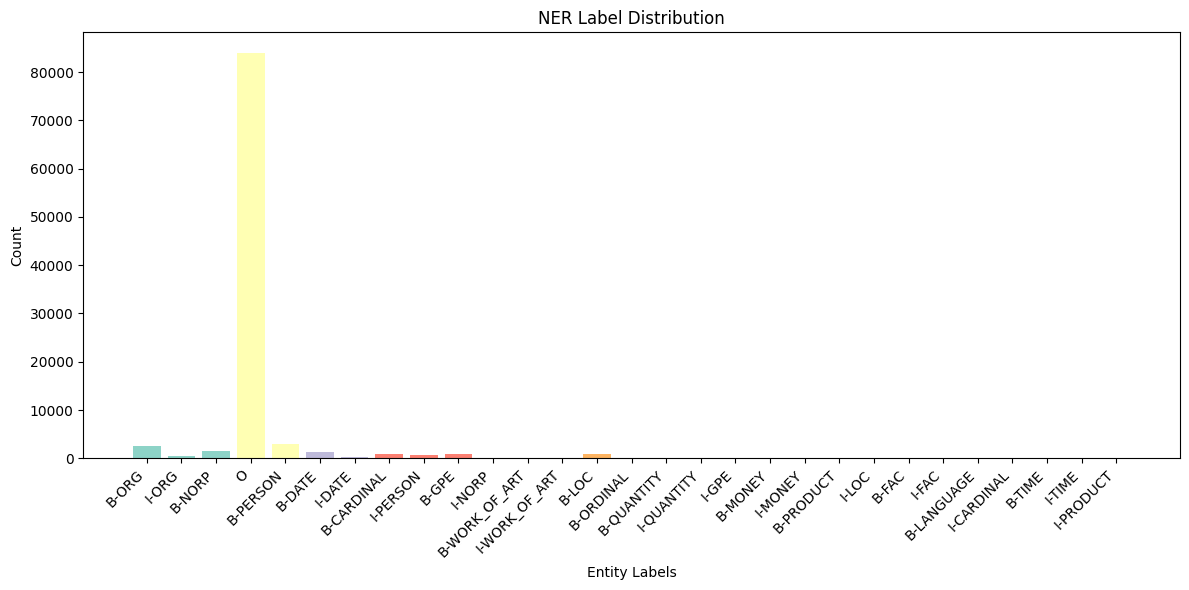

Saved: label_distribution.png


In [ ]:
# Visualization - Label Distribution
plt.figure(figsize=(12, 6))

labels = list(label_counts.keys())
counts = list(label_counts.values())

colors = plt.cm.Set3(np.linspace(0, 1, len(labels)))

plt.bar(labels, counts, color=colors)
plt.xlabel('Entity Labels')
plt.ylabel('Count')
plt.title('NER Label Distribution')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('label_distribution.png', dpi=150)
plt.show()

print("Saved: label_distribution.png")

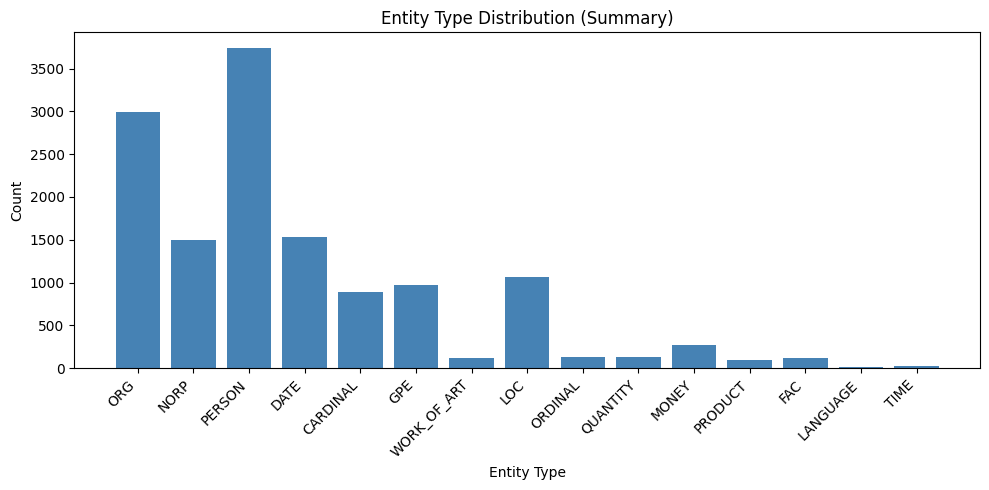

Saved: entity_distribution.png


In [ ]:
# Entity type summary (without B-/I- prefix)
entity_counts = {}
for label, count in label_counts.items():
    if label == 'O':
        continue
    entity_type = label[2:] if label.startswith('B-') or label.startswith('I-') else label
    entity_counts[entity_type] = entity_counts.get(entity_type, 0) + count

plt.figure(figsize=(10, 5))
entities = list(entity_counts.keys())
counts = list(entity_counts.values())

plt.bar(entities, counts, color='steelblue')
plt.xlabel('Entity Type')
plt.ylabel('Count')
plt.title('Entity Type Distribution (Summary)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('entity_distribution.png', dpi=150)
plt.show()

print("Saved: entity_distribution.png")

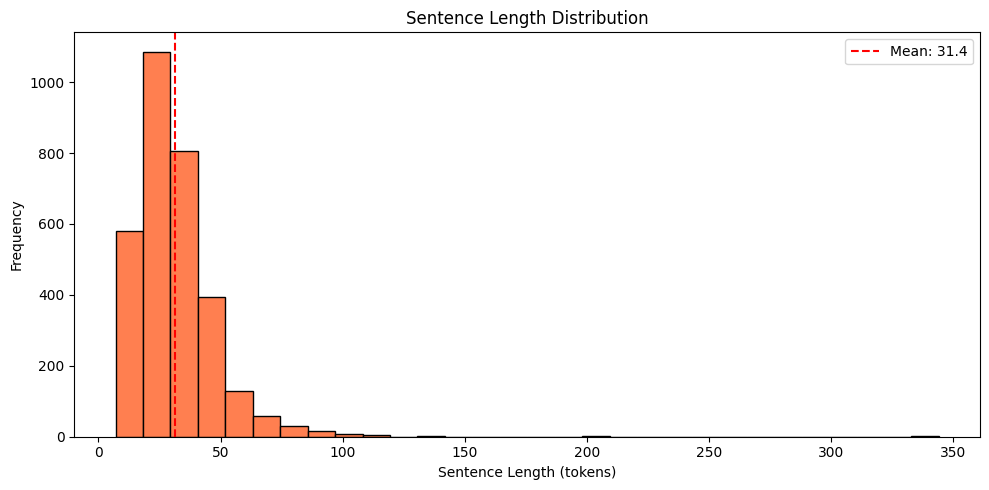

Mean length: 31.36
Max length: 344
Min length: 7


In [ ]:
# Sentence length distribution
sentence_lengths = df['tokens'].apply(len)

plt.figure(figsize=(10, 5))
plt.hist(sentence_lengths, bins=30, color='coral', edgecolor='black')
plt.xlabel('Sentence Length (tokens)')
plt.ylabel('Frequency')
plt.title('Sentence Length Distribution')
plt.axvline(sentence_lengths.mean(), color='red', linestyle='--', label=f'Mean: {sentence_lengths.mean():.1f}')
plt.legend()
plt.tight_layout()
plt.savefig('sentence_length_distribution.png', dpi=150)
plt.show()

print(f"Mean length: {sentence_lengths.mean():.2f}")
print(f"Max length: {sentence_lengths.max()}")
print(f"Min length: {sentence_lengths.min()}")

---

# Step 7: Prediction (Inference)

In [41]:
import torch
from transformers import AutoTokenizer, AutoModelForTokenClassification

# Load model
model_path = "./ner_model_final"
print(f"Loading model from {model_path}...")

tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForTokenClassification.from_pretrained(model_path)
model.eval()

print("Model loaded!")

Loading model from ./ner_model_final...


Loading weights: 100%|██████████| 102/102 [00:00<00:00, 1939.63it/s]

Model loaded!


In [42]:
# Fix: Load correct id2label from model config instead of label_mappings.json
import json

# Load from model's config (this has the correct mappings)
model_config = json.load(open('./ner_model_final/config.json'))
id2label = model_config['id2label']
label2id = model_config['label2id']

print("Loaded id2label from model config:")
print(id2label)
print(f"\nNumber of labels: {len(id2label)}")

Loaded id2label from model config:
{'0': 'B-CARDINAL', '1': 'B-DATE', '2': 'B-FAC', '3': 'B-GPE', '4': 'B-LANGUAGE', '5': 'B-LOC', '6': 'B-MONEY', '7': 'B-NORP', '8': 'B-ORDINAL', '9': 'B-ORG', '10': 'B-PERSON', '11': 'B-PRODUCT', '12': 'B-QUANTITY', '13': 'B-TIME', '14': 'B-WORK_OF_ART', '15': 'I-CARDINAL', '16': 'I-DATE', '17': 'I-FAC', '18': 'I-GPE', '19': 'I-LOC', '20': 'I-MONEY', '21': 'I-NORP', '22': 'I-ORG', '23': 'I-PERSON', '24': 'I-PRODUCT', '25': 'I-QUANTITY', '26': 'I-TIME', '27': 'I-WORK_OF_ART', '28': 'O'}

Number of labels: 29


In [43]:
def predict_ner(text, show_details=True):
    """
    Predict NER tags for input text.
    
    Args:
        text: Input sentence (string)
        show_details: If True, prints detailed results
    
    Returns:
        List of (word, entity) tuples
    """
    # Tokenize
    tokens = text.split()
    inputs = tokenizer(tokens, is_split_into_words=True, return_tensors="pt", truncation=True, padding=True)

    # Get predictions
    with torch.no_grad():
        outputs = model(**{k: v.to(model.device) for k, v in inputs.items()})
        predictions = torch.argmax(outputs.logits, dim=2).squeeze().tolist()

    # Map predictions back to words
    word_ids = inputs.word_ids()
    predictions_per_word = []
    previous_word_idx = None

    for idx, word_idx in enumerate(word_ids):
        if word_idx is None:
            continue
        elif word_idx != previous_word_idx:
            predictions_per_word.append(id2label[str(predictions[idx])])
        previous_word_idx = word_idx
    
    results = list(zip(tokens, predictions_per_word))

    if show_details:
        print(f"\nInput: {text}")
        print("-" * 40)
        print(f"{'TOKEN':<20} {'ENTITY':<15}")
        print("-" * 40)
        for token, pred in results:
            print(f"{token:<20} {pred:<15}")

        # Group entities
        print("\n" + "-" * 40)
        print("Grouped Entities:")
        print("-" * 40)
        current_entity = None
        entity_text = []
        for token, pred in results:
            if pred.startswith('B-'):
                if entity_text:
                    print(f"  {current_entity}: {' '.join(entity_text)}")
                current_entity = pred[2:]
                entity_text = [token]
            elif pred.startswith('I-') and current_entity == pred[2:]:
                entity_text.append(token)
            else:
                if entity_text:
                    print(f"  {current_entity}: {' '.join(entity_text)}")
                    entity_text = []
                current_entity = None
                if not pred.startswith('O'):
                    current_entity = pred[2:]
                    entity_text = [token]
        if entity_text:
            print(f"  {current_entity}: {' '.join(entity_text)}")

    return results

In [48]:
# Test predictions
test_sentences = [
    "Bill Clinton met with Donald Trump in Washington on January 15, 2024.",
    "The United States and China signed a trade agreement in New York.",
    "Apple Inc. CEO Tim Cook announced new products at the event.",
    "Google's headquarters is located in Mountain View, California.",
]

for sentence in test_sentences:
    predict_ner(sentence)
    print()


Input: Bill Clinton met with Donald Trump in Washington on January 15, 2024.
----------------------------------------
TOKEN                ENTITY         
----------------------------------------
Bill                 B-PERSON       
Clinton              I-PERSON       
met                  O              
with                 O              
Donald               B-PERSON       
Trump                I-PERSON       
in                   O              
Washington           B-GPE          
on                   O              
January              B-DATE         
15,                  B-CARDINAL     
2024.                B-DATE         

----------------------------------------
Grouped Entities:
----------------------------------------
  PERSON: Bill Clinton
  PERSON: Donald Trump
  GPE: Washington
  DATE: January
  CARDINAL: 15,
  DATE: 2024.


Input: The United States and China signed a trade agreement in New York.
----------------------------------------
TOKEN                ENTITY     

---

# Summary & Conclusion

## Pipeline Summary

| Step | Description | Output |
|------|-------------|--------|
| Day1 | Data Crawling | 3,680 sentences |
| Day2 | Preprocessing | 3,113 clean sentences |
| Day3 | NER Encoding | ner_dataset.pkl |
| Day4 | Auto-Labeling (Transformers) | manual_labeled.csv |
| Day4.5 | Relabeling (Custom Mappings) | relabeled_output.csv |
| Day5 | Model Training | ner_model_final/ |
| Day6 | Results & Viz | label_distribution.png |

## Model Performance
- Model: DistilBERT (distilbert-base-uncased)
- Training Epochs: 5
- Batch Size: 16
- Learning Rate: 2e-5

## Entities Recognized
- PERSON: People names
- ORG: Organizations
- GPE: Geopolitical entities (countries, cities)
- DATE: Dates
- MONEY: Monetary values
- CARDINAL: Numbers
- NORP: Nationalities/Religious/Political groups
- And more...

## Future Improvements
- Fine-tune with more epochs
- Increase dataset size
- Use larger models (BERT, RoBERTa)
- For Vietnamese: Use PhoBERT
- Implement active learning for better labeling